# Setup

In [275]:
import dataclasses

import jax

from openpi.models import model as _model
from openpi.policies import droid_policy
from openpi.policies import policy_config as _policy_config
from openpi.shared import download
from openpi.training import config as _config
from openpi.training import data_loader as _data_loader
from openpi_client import image_tools

import Pyro5.api
import numpy as np

import time
import pickle
import os
import atexit


## Loading a model

In [ ]:
%env CUDA_VISIBLE_DEVICES=0,1
# load the model
config = _config.get_config("pi0_RPM_low_mem_finetune")  # change config in config.py as needed

# prompt
# PROMPT = "Pick up the blue block" # MAKE SURE TO CHANGE THIS
# PROMPT = "Put the green block in the pot" # MAKE SURE TO CHANGE THIS
PROMPT = "Set the cup upright" # MAKE SURE TO CHANGE THIS

# load checkpoint
# checkpoint_dir = '/data/checkpoints/pi0_RPM_low_mem_finetune/pickblueblock_bottomleft_topright/29999'
# checkpoint_dir = '/data/checkpoints/pi0_RPM_low_mem_finetune/putgreeninpot_bottomleft_topright/lid_on/29999'
checkpoint_dir = '/data/checkpoints/pi0_RPM_low_mem_finetune/uprightcup_bottomleft_topright/29999'

# Create a trained policy.
policy = _policy_config.create_trained_policy(config, checkpoint_dir)

env: CUDA_VISIBLE_DEVICES=0,1


In [274]:
# delete current policy to free up memory, then load a new one
del policy

In [ ]:
# Run inference on a dummy example. This example corresponds to observations produced by the DROID runtime.
# example = droid_policy.make_droid_example()
# result = policy.infer(example)
# print("Actions shape:", result["actions"].shape)

## Initialize and test cameras

In [279]:
import pyrealsense2 as rs
import numpy as np
import cv2
import matplotlib.pyplot as plt

class RealSenseCamera:
    def __init__(self, serial_number, width=640, height=480, fps=30):
        self.pipeline = rs.pipeline()
        self.config = rs.config()
        self.config.enable_device(serial_number)
        # Enable color and depth streams
        self.config.enable_stream(rs.stream.depth, width, height, rs.format.z16, fps)
        self.config.enable_stream(rs.stream.color, width, height, rs.format.bgr8, fps) # Use BGR for easier OpenCV conversion

        # Start pipeline and create align object
        self.pipeline.start(self.config)
        self.align = rs.align(rs.stream.color)
        print(f"Camera {serial_number} started.")

    def get_frames(self):
        frames = self.pipeline.wait_for_frames()

        # Align frames
        aligned_frames = self.align.process(frames)
        depth_frame = aligned_frames.get_depth_frame()
        color_frame = aligned_frames.get_color_frame()

        if not color_frame or not depth_frame:
            return None, None # Return None for both if one fails

        bgr = np.asanyarray(color_frame.get_data())
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

        # depth image
        depth_image_raw = np.asanyarray(depth_frame.get_data())
        # Scale depth to 8-bit for saving like in data_collection.py (adjust alpha as needed)
        depth_image_scaled = cv2.convertScaleAbs(depth_image_raw, alpha=0.03)

        return rgb, depth_image_scaled

    def release(self):
        self.pipeline.stop()


# initialize cameras
serial_head = "f1380660"
serial_wrist = "130322273305"
cam_head = RealSenseCamera(serial_head)
cam_wrist = RealSenseCamera(serial_wrist)

Camera f1380660 started.
Camera 130322273305 started.


In [99]:
# Don't run unless necessary
cam_head.release()
cam_wrist.release()

RuntimeError: stop() cannot be called before start()

# Optional: Compare ground truth actions with predicted actions

In [44]:
# Get ground truth state and actions for comparison from a trajectory (.pkl file)
import pickle

def get_pickle_values(pickle_file_path, keys=None):
    """Extract and display the contents of a trajectory and store them."""
    try:
        with open(pickle_file_path, 'rb') as f:
            data = pickle.load(f)
        # Initialize a dict to store keys and their values
        value_dict = {}
        # If it's a dictionary, display the keys and values
        if isinstance(data, dict):
            # print(data['meta'])
            for key, value in data.items():
                # print(type(value))
                if isinstance(value, list):
                    # print(f"- {key}: List of length {len(value)}")
                    for timestep in value:
                        for k in keys:
                            if k in timestep:
                                value_dict.setdefault(k, []).append(timestep[k])

                        # print(timestep.keys())
                        # print(timestep['joint_positions'])
                        # print(timestep['eef_pose']['position'], timestep['eef_pose']['orientation_rpy'])
                        # print(timestep['gripper_state'])
                        # action_list.append((timestep['spark_command_angles'], timestep['spark_command_gripper']))
    except Exception as e:
        print(f"Error opening {pickle_file_path}: {e}")

    return value_dict

GT_path = '/data/shared_data/real_world_data/pickblueblock_blackbowl/traj_1758307262.pkl'
GT_dict = get_pickle_values(GT_path, keys=['joint_positions', 'eef_pose', 'gripper_state', 'spark_command_angles', 'spark_command_gripper'])

In [ ]:
# Get ground truth actions
GT_actions = []
for i, j in zip(GT_dict['spark_command_angles'], GT_dict['spark_command_gripper']):
    GT_actions.append([*i, j])

In [10]:
# Get all the frames from trajectory videos
import cv2
import numpy as np
# Assuming 'image_tools' is available in your environment for resizing
# import image_tools 

# observation.image_scene and observation.image_wrist videos
video_scene = '/home/liao0241/.cache/huggingface/lerobot/iamandrewliao/pickblueblock_blackbowl/videos/chunk-000/observation.image_scene/episode_000000.mp4'
video_wrist = '/home/liao0241/.cache/huggingface/lerobot/iamandrewliao/pickblueblock_blackbowl/videos/chunk-000/observation.image_wrist/episode_000000.mp4'

# Extract all the frames from both videos
frames_scene = []
frames_wrist = []

# Initialize video capture objects
cap_head = cv2.VideoCapture(video_scene)
cap_wrist = cv2.VideoCapture(video_wrist)

# Basic check to ensure videos opened
if not cap_head.isOpened():
    raise IOError(f"Error opening head camera video: {video_scene}")
if not cap_wrist.isOpened():
    raise IOError(f"Error opening wrist camera video: {video_wrist}")

# Set up a loop to read frames until both videos have ended
# We use two separate return flags (ret_head, ret_wrist) to control the process.
ret_head = True
ret_wrist = True

while ret_head or ret_wrist:
    # Read the next frame from the videos
    # Note: We must read even if one video has ended, in case the other hasn't.
    ret_head, frame_head = cap_head.read()
    ret_wrist, frame_wrist = cap_wrist.read()

    # --- Frame Processing and Storage ---

    # Process the scene (head) camera frame if it was successfully read
    if ret_head:
        # Convert from BGR (OpenCV default) to RGB
        frame_head_rgb = cv2.cvtColor(frame_head, cv2.COLOR_BGR2RGB)
        frames_scene.append(frame_head_rgb)

    # Process the wrist camera frame if it was successfully read
    if ret_wrist:
        # Convert from BGR (OpenCV default) to RGB
        frame_wrist_rgb = cv2.cvtColor(frame_wrist, cv2.COLOR_BGR2RGB)
        frames_wrist.append(frame_wrist_rgb)

    # Termination check: Exit the loop when neither video successfully returns a frame
    if not ret_head and not ret_wrist:
        break

# IMPORTANT: Release the video capture objects
cap_head.release()
cap_wrist.release()

print(f"Successfully extracted {len(frames_scene)} frames from the scene video.")
print(f"Successfully extracted {len(frames_wrist)} frames from the wrist video.")

Successfully extracted 173 frames from the scene video.
Successfully extracted 173 frames from the wrist video.


In [ ]:
# Get action predictions for trajectory
pred_actions = []
for i in range(len(frames_scene)):
    observation = {
        'observation.image_scene': frames_scene[i],
        'observation.image_wrist': frames_wrist[i],
        'observation.state': np.concatenate(
            (GT_dict['joint_positions'][i], GT_dict['eef_pose'][i]['position'], GT_dict['eef_pose'][i]['orientation_rpy'], [GT_dict['gripper_state'][i]])
            ),
        "prompt": PROMPT
    }
    result = policy.infer(observation)  # to get just one action, I changed 'action_horizon' in pi0_config.py to 1
    pred_actions.append(result['actions'])

In [120]:
import numpy as np

def clip_action(action_array, max_norm):
    """
    Clips a single action vector based on its L2 norm.
    
    Args:
        action_array (np.ndarray): The predicted action, expected shape (1, 7).
        max_norm (float): The maximum allowed L2 norm.
        
    Returns:
        np.ndarray: The clipped or original action array.
    """
    # Fix 1: Corrected numpy linear algebra module name
    # Fix 2: Flatten the (1, 7) array to a 7-element vector for norm calculation
    # We use .flatten()[0] to access the first (and only) row if it's (1, 7)
    action_vector = action_array.flatten()
    
    # Calculate the L2 norm (Euclidean distance)
    norm = np.linalg.norm(action_vector)
    
    # Check if the norm exceeds the maximum
    if norm > max_norm:
        # Scale down the vector to the max_norm while preserving its direction
        # Note: We must return the result in the original shape (1, 7)
        clipped_vector = (action_vector / norm) * max_norm
        clipped_action_array = clipped_vector.reshape(1, -1)
        
        # print(f"Action clipped. Original norm: {norm:.4f}, New norm: {max_norm:.4f}")
        return clipped_action_array, 1
    else:
        # print(f"Action not clipped. Norm: {norm:.4f}")
        return action_array, 0
    

# Choose an appropriate max norm based on your robot's capabilities. 
MAX_NORM = 4

clipped_pred_actions = []
clipped = 0

for pred_action in pred_actions:
    clipped_action, s = clip_action(pred_action, MAX_NORM)
    clipped += s
    clipped_pred_actions.append(clipped_action)

print(f"Number of actions clipped: {clipped}")

Number of actions clipped: 173


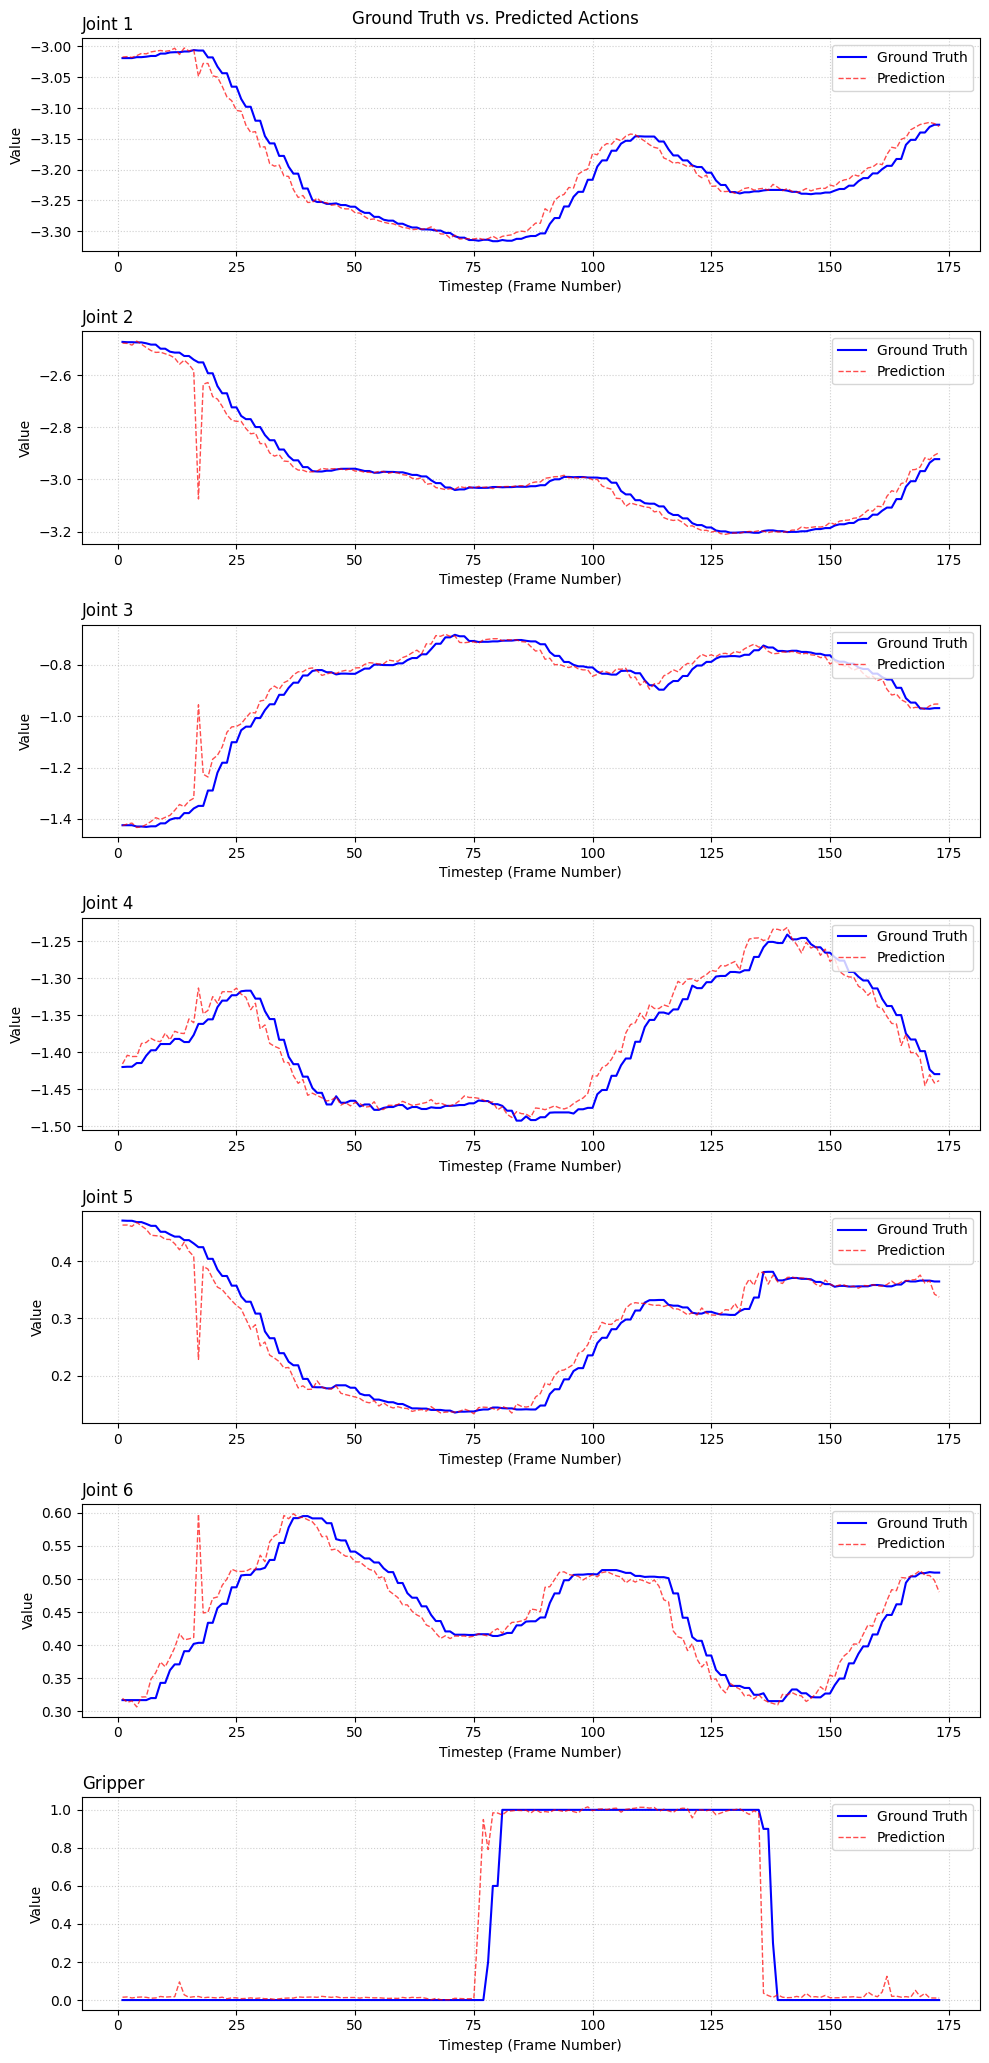

In [122]:
import matplotlib.pyplot as plt

labels = [f"Joint {i+1}" for i in range(6)] + ["Gripper"]
DOF = 7
timesteps = np.arange(1, len(GT_actions)+1)
PREDICTED_ACTIONS = pred_actions

fig, axes = plt.subplots(
    nrows=DOF, 
    ncols=1, 
    figsize=(10, 3 * DOF), # Adjust height for all subplots
)
fig.suptitle('Ground Truth vs. Predicted Actions')

for i in range(DOF):
    ax = axes[i]
    ax.plot(
        timesteps, 
        [a_t[i] for a_t in GT_actions], 
        label='Ground Truth', color='blue', linestyle='-', linewidth=1.5
    )
    ax.plot(
        timesteps, 
        [a_t[0][i] for a_t in PREDICTED_ACTIONS], 
        label='Prediction', 
        color='red', linestyle='--', linewidth=1.0, alpha=0.7
    )
    
    # Set titles and labels
    ax.set_title(labels[i], loc='left')
    ax.set_ylabel('Value')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='upper right')
    ax.set_xlabel('Timestep (Frame Number)')

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()    


In [ ]:
# # action clipping
# def clip_action(action, max_norm):
#     norm = np.lingalg.norm(action)
#     if norm > max_norm:
#         # Scale down the vector to the max_norm while preserving its direction
#         clipped_action = (action / norm) * max_norm
#         print(f"Action clipped. Original norm: {norm:.4f}, New norm: {max_norm:.4f}")
#         return clipped_action
#     else:
#         # If the norm is within the threshold, return the original action
#         print(f"Action not clipped. Norm: {norm:.4f}")
#         return action

# Actual deployment

In [ ]:
# SAVE_DIR = "/data/UR_teleop/uprightcup/deployment_trajs/bruteforce"
# os.makedirs(SAVE_DIR, exist_ok=True)

# # Use a dictionary to hold the trajectory list so atexit gets the reference
# trajectory_data = {'frames': []} # Use a dictionary wrapper

# def save_trajectory(traj_data, save_dir, lang_instruction):
#     frames_to_save = traj_data['frames']
#     # --- Prevent saving if no frames were collected ---
#     if not frames_to_save:
#         print("\nNo frames collected, skipping save.")
#         return # Exit the function early

#     traj_id = int(time.time())
#     filename = f"traj_{traj_id}.pkl"
#     save_path = os.path.join(save_dir, filename)

#     # Mimic the structure from data_collection.py
#     traj_dict = {
#         "meta": {
#             "traj_id": traj_id,
#             "date": time.strftime("%Y-%m-%d %H:%M:%S", time.localtime(traj_id)),
#             "lang_instruction": lang_instruction  # Get from first frame
#         },
#         "frames": frames_to_save
#     }

#     try:
#         with open(save_path, 'wb') as f:
#             pickle.dump(traj_dict, f, protocol=pickle.HIGHEST_PROTOCOL)    
#         print(f"\nTrajectory saved successfully: {save_path}")
#         print(f"Trajectory length: {len(frames_to_save)} steps.")
#         print("Clearing collected trajectory data for next run.")
#         frames_to_save.clear()
#     except Exception as e:
#         print(f"\n[ERROR] Failed to save trajectory: {e}")

In [ ]:
# --- Connect to Controller ---
try:
    ns = Pyro5.api.locate_ns()
    uri = ns.lookup("pi0_controller")
    controller = Pyro5.api.Proxy(uri)
    print("Connected to controller.")
except Exception as e:
    print(f"[ERROR] Could not connect to controller. {e}")
    controller = None # Ensure controller is None if connection fails

# --- Deployment Settings ---
MAX_POLICY_STEPS = 500 # Set a max number of policy steps
EXECUTION_NUM = 16 # Make sure this matches deploy.py
IMG_SIZE = 224 # For policy input resizing

# Get Initial State
initial_obs_state = None
if controller:
    try:
        print("\nRequesting initial state from controller...")
        # Send a dummy action chunk to get the initial state
        dummy_action_chunk = [np.zeros(7).tolist()] * EXECUTION_NUM
        # dummy_action_chunk = np.zeros((config.model.action_horizon,7), dtype=np.float32)
        initial_data_to_send = {
            "type": "action",
            "data": dummy_action_chunk,
            "step": 0 # Indicate it's the initial step
        }
        initial_result = controller.step(initial_data_to_send)
        initial_obs_state = initial_result["final_state"] # Get the state after the dummy 'execution'
        print("Initial state received.")
        # print("Initial obs state:", initial_obs_state) # Optional: print for debugging
    except Exception as e:
        print(f"[ERROR] Failed to get initial state from controller: {e}")
        initial_obs_state = None # Ensure state is None if failed

# Deployment Loop
current_obs_state = initial_obs_state

if current_obs_state and cam_head and cam_wrist and controller: # Check if all components are ready
    print("\nStarting deployment loop...")
    try: # Wrap the loop in try/except/finally
        for step in range(1, MAX_POLICY_STEPS + 1): # Start from step 1 for actual execution
            loop_start_time = time.time()
            print(f"--- Policy Step {step} ---")

            # Get current timestamp and images
            step_timestamp = time.time()
            img_head_rgb, img_head_depth_scaled = cam_head.get_frames()
            img_wrist_rgb, img_wrist_depth_scaled = cam_wrist.get_frames()

            # Resize/pad images for policy input
            img_head_resized = image_tools.resize_with_pad(img_head_rgb, IMG_SIZE, IMG_SIZE)
            img_wrist_resized = image_tools.resize_with_pad(img_wrist_rgb, IMG_SIZE, IMG_SIZE)

            # Construct Observation for Policy (using state from *previous* step's end)
            joint_pos = np.array(current_obs_state["joint_positions"], dtype=np.float32)
            # eef_pos = np.array(current_obs_state["eef_pose"]["position"], dtype=np.float32)
            # eef_rpy = np.array(current_obs_state["eef_pose"]["orientation_rpy"], dtype=np.float32)
            # gripper_state_normalized = np.array([current_obs_state["gripper_state"] / 255.0], dtype=np.float32)
            gripper_state_raw = np.array([current_obs_state["gripper_state"]], dtype=np.float32) # CHANGE IN FUTURE (I fixed the issue in convert_to_lerobot.py already)
            policy_state_vector = np.concatenate([joint_pos, gripper_state_raw])

            obs_for_policy = {
                "observation.image_scene": img_head_resized,
                "observation.image_wrist": img_wrist_resized,
                "observation.state": policy_state_vector,
                "prompt": PROMPT,
            }

            # Policy Inference
            inference_start_time = time.time()
            policy_result = policy.infer(obs_for_policy)
            action_chunk = policy_result["actions"].tolist()
            inference_end_time = time.time()

            # Prepare data and send to controller
            data_to_send = {
                "type": "action",
                "data": action_chunk,
                "step": step
            }
            controller_start_time = time.time()
            result_data = controller.step(data_to_send)
            controller_end_time = time.time()

            # Update state for the next iteration
            current_obs_state = result_data["final_state"]

            loop_end_time = time.time()


    except Exception as e: 
        print(f"\n[ERROR] An error occurred during deployment: {e}")

else:
    print("\n[ERROR] Deployment cannot start due to initialization failures (camera, controller, or getting initial state).")

Connected to controller.

Requesting initial state from controller...
Initial state received.

Starting deployment loop...
--- Policy Step 1 ---
--- Policy Step 2 ---
--- Policy Step 3 ---
--- Policy Step 4 ---
--- Policy Step 5 ---
--- Policy Step 6 ---
--- Policy Step 7 ---
--- Policy Step 8 ---
--- Policy Step 9 ---
--- Policy Step 10 ---
--- Policy Step 11 ---
--- Policy Step 12 ---
--- Policy Step 13 ---
--- Policy Step 14 ---
--- Policy Step 15 ---
--- Policy Step 16 ---
--- Policy Step 17 ---
--- Policy Step 18 ---
--- Policy Step 19 ---


In [278]:
cam_head.release()
cam_wrist.release()